### Osculating elements for a disk (from Foschi et al. 2026)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from perseo import *
from perseo.constants import G, c, Msun, degree_to_rad

#### Star parameters

In [2]:
M = 4.29e6*Msun              # Sgr A* mass [kg]
a = 1.5e14                   # semi-major axis [m]
e = 0.88
p = a*(1-e**2) 
iORB = 134.7*degree_to_rad
omega = 66.3*degree_to_rad + np.pi
Omega = 228.2*degree_to_rad + np.pi #note the shift by a factor pi as explained in Foschi et al. (2026)

r_peri = p/(1 - e*np.cos(0.0))
r_apo = p/(1 - e*np.cos(np.pi))
elements0 = (p, e, iORB, omega, Omega)   # p, e, i, omega, Omega

#### Disk parameters

In [11]:
Mdisk = 1e3*Msun
r_min = r_peri
r_max = r_apo
ibh = 90*degree_to_rad
beta = 0
alpha = 2

### Variations for 1 PN + DISK

In [12]:
perturbations = [make_onePN(M),
                 make_powerlaw_disk(Mdisk, r_min, r_max, ibh, beta, alpha, log_spacing=False)]

f, y = integrate_orbit(elements0, perturbations, M)

d = element_changes(f, y, elements0, angle_units='deg')


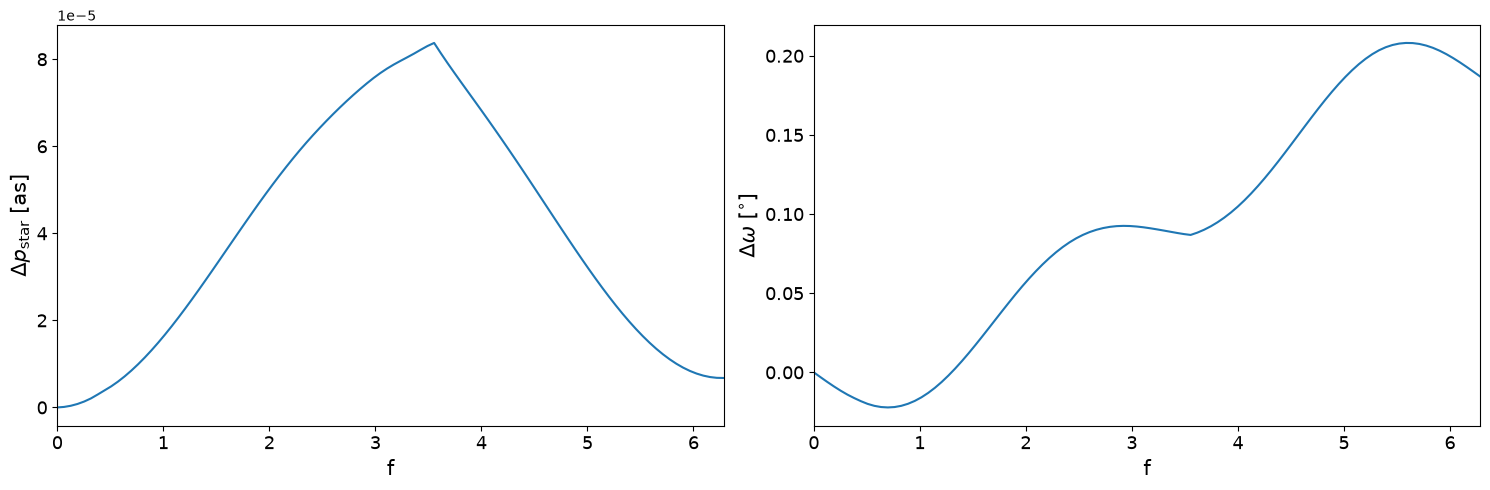

In [13]:
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(f, d["p"])
ax1.set_ylabel("$\\Delta p_{\\text{star}}$ [as]", fontsize = 15)
ax1.tick_params(axis='both', labelsize=13)
ax1.set_xlabel("f", fontsize = 15)
ax1.set_xlim(0, 2*np.pi)

ax2.plot(f, d["omega"])
ax2.set_ylabel("$\\Delta \\omega$ [$^{\\circ}$]", fontsize = 15)
ax2.set_xlabel("f", fontsize = 15)
ax2.set_xlim(0, 2*np.pi)
ax2.tick_params(axis='both', labelsize=13)

plt.tight_layout()
#plt.savefig('deltap_new.pdf', bbox_inches='tight')

### Disk only
Here the inclination changes to reproduce the figures in Foschi et al. (2026)

In [14]:
ibh = 2*degree_to_rad
perturbations = [make_powerlaw_disk(Mdisk, r_min, r_max, ibh, beta, alpha, log_spacing=False)]

f, y = integrate_orbit(elements0, perturbations, M)

d = element_changes(f, y, elements0, angle_units='deg')

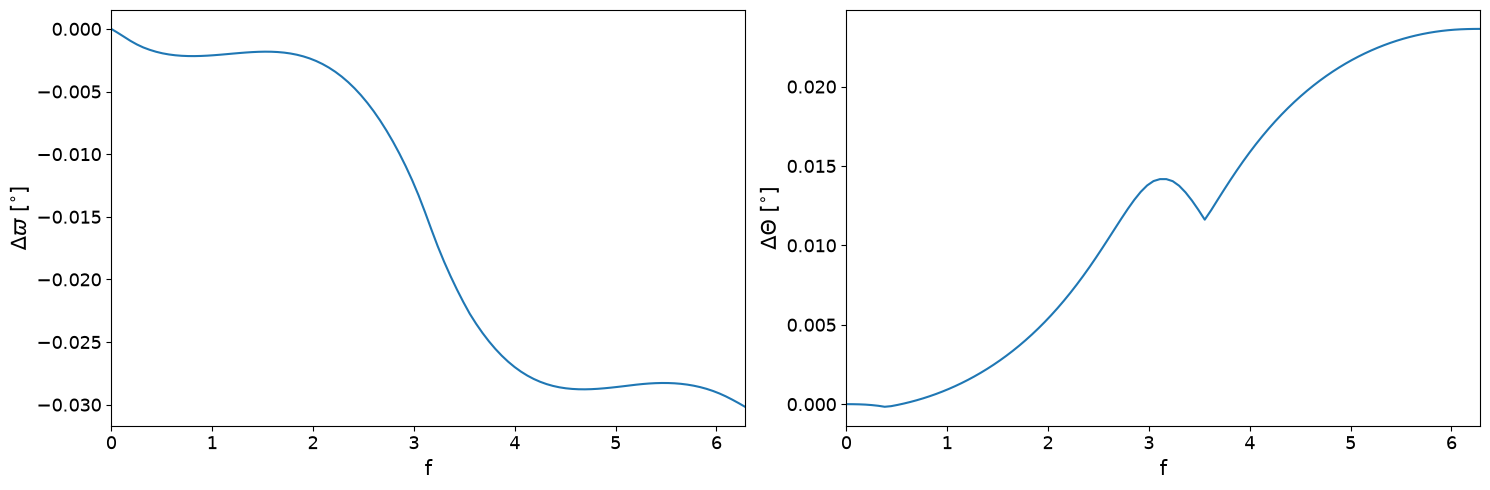

In [15]:
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(f, d["varpi"])
ax1.set_ylabel("$\\Delta \\varpi$ [$^{\\circ}$]", fontsize = 15)
ax1.tick_params(axis='both', labelsize=13)
ax1.set_xlabel("f", fontsize = 15)
ax1.set_xlim(0, 2*np.pi)

ax2.plot(f, d["Theta"])
ax2.set_ylabel("$\\Delta \\Theta$ [$^{\\circ}$]", fontsize = 15)
ax2.set_xlabel("f", fontsize = 15)
ax2.set_xlim(0, 2*np.pi)
ax2.tick_params(axis='both', labelsize=13)

plt.tight_layout()
